In [ ]:
import zipfile
import io
import pandas as pd

#link to dataset https://open.toronto.ca/dataset/bike-share-toronto-ridership-data/
zip_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/8c233bc2-1879-44ff-a0e4-9b69a9032c54/resource/3263cbd6-39f8-46c9-8ca6-bd8ffc730157/download/parking-tickets-2024.zip"
response = requests.get(zip_url)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open(z.namelist()[0]) as f:
        df = pd.read_csv(f)

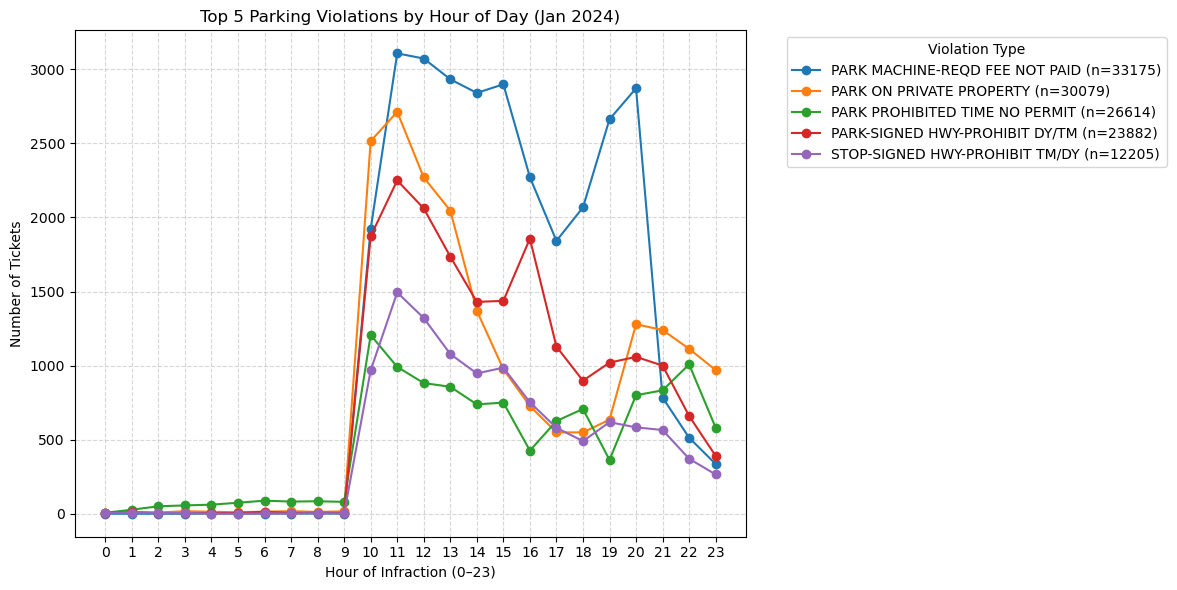

In [ ]:
import matplotlib.pyplot as plt

# Extract and clean the hour of infraction
df = df[df['time_of_infraction'].notnull()]
df['time_str'] = df['time_of_infraction'].astype(str).str.zfill(4)  # pad to 4 digits
df['hour'] = df['time_str'].str[:2].astype(int)

# Identify the top 5 most common violations and their total counts
top5_counts = df['infraction_description'].value_counts().nlargest(5)
top5_violations = top5_counts.index.tolist()

# Filter the dataframe to only these top 5
df_top5 = df[df['infraction_description'].isin(top5_violations)]

# Group by hour and infraction, then pivot to wide format
grouped = (
    df_top5
    .groupby(['hour', 'infraction_description'])
    .size()
    .unstack(fill_value=0)
)

# Ensure we have rows for every hour 0–23
grouped = grouped.reindex(range(24), fill_value=0)

# Plot
plt.figure(figsize=(12, 6))
# Show the total number of violation for Top 5 parking violations
for violation in grouped.columns:
    total = top5_counts[violation]
    label = f"{violation} (n={total})"
    plt.plot(grouped.index, grouped[violation], marker='o', label=label)

plt.title("Top 5 Parking Violations by Hour of Day (Jan 2024)")
plt.xlabel("Hour of Infraction (0–23)")
plt.ylabel("Number of Tickets")
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Violation Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()